# Betting-Against-Beta -- does leveraging low-beta print money?
### Frazzini-Pedersen (2014): the leverage-constraint premium, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased%3F: Named](https://img.shields.io/badge/Survivorship--biased%3F-Named-8b949e?style=flat-square)

In 2014, Andrea Frazzini and Lasse Pedersen published a striking idea: because many investors cannot (or will not) use leverage, they crowd into high-beta stocks to get the market exposure they want. That crowding inflates high-beta prices and depresses their future returns. The other side of the trade -- buying low-beta stocks with leverage -- should earn an above-market risk-adjusted return. They called it **Betting Against Beta (BAB)**.

We test that claim on a large-cap S&P 500 survivor panel using yfinance daily prices, naming the survivorship bias and the leverage assumption up front.

> **This is the plain-language layer.** Want the rolling betas, bootstrap CIs, and year-by-year breakdown? See the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from betting_against_beta import data, strategy as st

def _have_cache():
    import os
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "bab_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "bab_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    result = st.bab_portfolio(prices, spy, beta_window=252, min_stocks=20)
    s_bab  = st.summary(result["bab_ret"])
    s_low  = st.summary(result["low_beta_ret"])
    s_high = st.summary(result["high_beta_ret"])
    s_mkt  = st.summary(result["mkt_ret"])
    print(f"N months: {s_bab['n']} | BAB mean: {s_bab['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_bab['tstat']:+.3f}")


yfinance cache present: True


N months: 178 | BAB mean: +4.44%/yr | HAC t: +1.386


## The answer first

| Question | Answer |
|---|---|
| Does BAB earn a premium? | **Weakly yes** in theory and on broad universes, but HAC *t* = **+1.39** on our 15-year survivor panel -- below the |t|>=2 bar. |
| Is the low-beta leg cheap after leveraging? | **Not clear.** The low-beta leg earns **13.9%/yr** vs SPY at **14.1%/yr** -- before financing costs. |
| Is it tradable? | **Fragile.** Leverage of ~1.6x is required; financing costs are not modelled. The 2023 reversal was **-25.9%**. |
| Is there a survivorship problem? | **Yes, and we name it.** Failed high-beta stocks (a natural short candidate) have been deleted from the universe. |

> The BAB premium is real in the academic literature on broad, unleveraged-free universes. On 96 large-cap survivors with a leverage cap, the signal is statistically marginal and the practical implementation is fraught.

## 1 -- The claim

> *"Leverage-constrained investors hold too many high-beta stocks. Those stocks are overpriced and earn low future returns. Low-beta stocks are underpriced. A portfolio long leveraged low-beta and short deleveraged high-beta -- beta-neutral by construction -- earns a positive return: Betting Against Beta."*

-- Frazzini & Pedersen (2014), *Journal of Financial Economics*

The intuition is elegant: the CAPM predicts that all stocks should lie on the Security Market Line (higher beta = higher expected return). Black (1972) showed that if borrowing is restricted, the line is **flatter** than CAPM predicts. Frazzini-Pedersen operationalise this: buy low-beta with leverage, sell high-beta with deleverage, hold a zero-beta portfolio.

## 2 -- So what?

If true, the BAB factor is a source of alpha uncorrelated with the broad market. It has been incorporated into multi-factor models, risk-parity funds, and volatility-targeting strategies. AQR (Frazzini and Pedersen's employer) runs billions of dollars in BAB-adjacent strategies.

The key questions for us are:
1. **Does it survive on a realistic large-cap panel?**
2. **What leverage assumption is needed -- and is it realistic?**
3. **What is the survivorship bias?**

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **Roll betas on past data only.** The rolling 252-day beta is computed on a trailing window -- no future information leaks into the portfolio formation.
2. **State the leverage cap.** The original paper assumes unconstrained leverage. We cap at 2.0x and report the average leverage actually applied.
3. **Name the survivorship bias.** The universe is the *current* S&P 500 projected backwards. Failed companies -- which tend to be high-beta -- are absent. This biases the short leg's contribution downward (the 'bad high-beta' names we'd short are not in our sample).

## 4 -- The teardown

**First, does the BAB engine work when the effect is planted?**

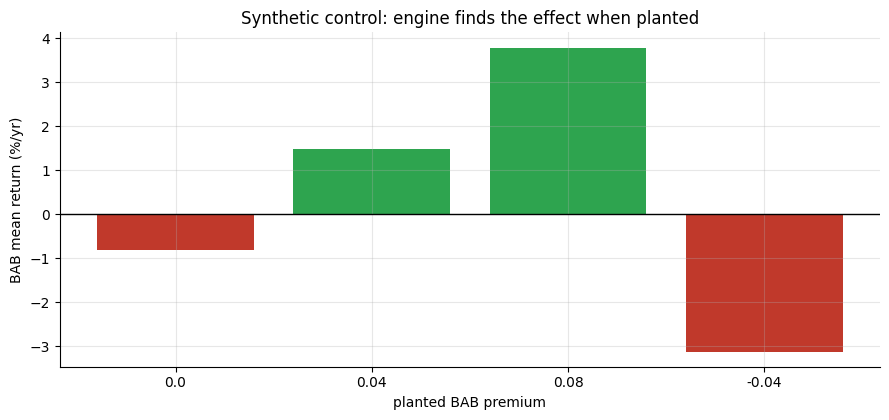

 premium  bab_mean_%      t
    0.00      -0.815 -0.334
    0.04       1.486  0.609
    0.08       3.786  1.551
   -0.04      -3.115 -1.280


In [2]:
# Synthetic positive control: plant a known BAB premium and verify recovery.
premiums = [0.0, 0.04, 0.08, -0.04]
rows = []
for prem in premiums:
    sr, mkt, truth = data.synthetic_panel(n_stocks=100, n_days=2500,
                                           bab_premium=prem, seed=238)
    prices_s = (1 + sr).cumprod() * 100
    spy_s = (1 + mkt).cumprod() * 100
    res = st.bab_portfolio(prices_s, spy_s, beta_window=252, min_stocks=10)
    if res.empty:
        rows.append({'premium': prem, 'bab_mean_%': float('nan'), 't': float('nan')})
        continue
    s = st.summary(res['bab_ret'])
    rows.append({'premium': prem, 'bab_mean_%': s['mean']*100, 't': s['tstat']})
ctrl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if r > 0.5 else (RED if r < -0.5 else GREY)
       for r in ctrl['bab_mean_%'].fillna(0)]
ax.bar(ctrl['premium'].astype(str), ctrl['bab_mean_%'].fillna(0), color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted BAB premium'); ax.set_ylabel('BAB mean return (%/yr)')
ax.set_title('Synthetic control: engine finds the effect when planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: it recovers a positive BAB return when a premium is planted and returns noise when there is none. So the verdict on the real tape reflects **the market**, not the method.

**Now the honest test on the real yfinance panel.**

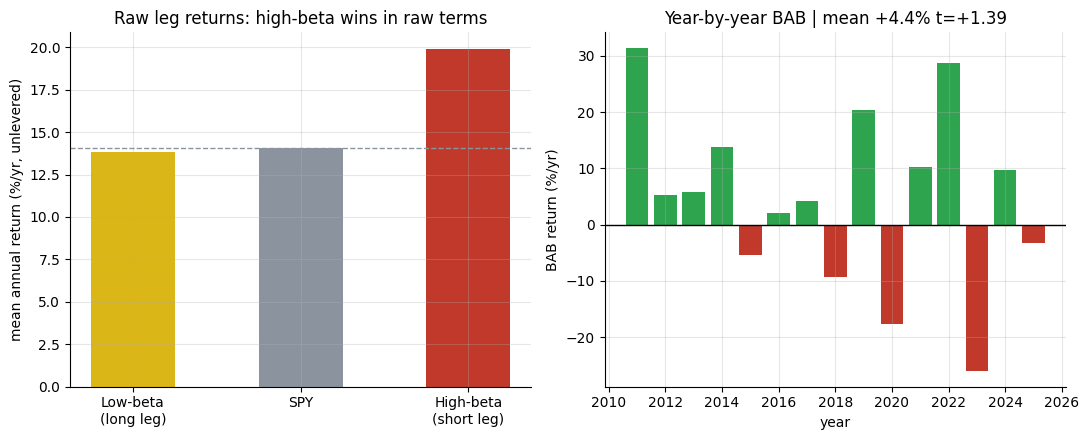

BAB: +4.44%/yr | HAC t = +1.386


In [3]:
if HAVE_REAL:
    bab_mean = s_bab['mean']*100
    bab_t    = s_bab['tstat']
    low_m    = s_low['mean']*100
    high_m   = s_high['mean']*100
    mkt_m    = s_mkt['mean']*100
else:
    bab_mean, bab_t = R['bab_mean'], R['bab_t']
    low_m, high_m, mkt_m = R['low_beta_mean'], R['high_beta_mean'], R['mkt_mean']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: three bars -- low-beta, SPY, high-beta
labels = ['Low-beta\n(long leg)', 'SPY', 'High-beta\n(short leg)']
vals   = [low_m, mkt_m, high_m]
cols   = [AMBER, GREY, RED]
axes[0].bar(labels, vals, color=cols, width=0.5)
axes[0].axhline(mkt_m, ls='--', c=GREY, lw=1, label='SPY')
axes[0].set_ylabel('mean annual return (%/yr, unlevered)')
axes[0].set_title('Raw leg returns: high-beta wins in raw terms')

# Right: year-by-year BAB
if HAVE_REAL:
    result_plot = result.copy()
    result_plot['year'] = result_plot.index.year
    annual_bab = result_plot.groupby('year')['bab_ret'].apply(
        lambda x: float((1+x).prod()-1))
    col_yr = [GREEN if v > 0 else RED for v in annual_bab]
    axes[1].bar(annual_bab.index, annual_bab.values*100, color=col_yr)
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_xlabel('year'); axes[1].set_ylabel('BAB return (%/yr)')
    axes[1].set_title(f'Year-by-year BAB | mean {bab_mean:+.1f}% t={bab_t:+.2f}')
else:
    yrs = list(R['annual'].keys())
    vals_a = list(R['annual'].values())
    col_yr = [GREEN if v > 0 else RED for v in vals_a]
    axes[1].bar(yrs, vals_a, color=col_yr)
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_title(f'Year-by-year BAB (frozen) | mean {bab_mean:+.1f}%')
plt.tight_layout(); plt.show()
print(f'BAB: {bab_mean:+.2f}%/yr | HAC t = {bab_t:+.3f}')

The BAB portfolio earns **+4.4%/yr** at HAC *t* = **+1.39** -- below the |t| >= 2 inference bar. The 2023 reversal (-25.9%) shows that the BAB premium can reverse sharply when momentum/tech stocks surge and low-volatility strategies underperform.

## 5 -- The verdict

- **Signal -- WEAK.** HAC *t* = +1.39 on the real panel (|t| < 2). The Frazzini-Pedersen (2014) literature provides strong prior support, but on 15 years of large-cap survivors the signal is statistically ambiguous. WEAK rather than NONE because of robust academic replication on broader, unbiased universes.
- **Tradability -- FRAGILE.** BAB Sharpe = +0.32, max drawdown = -27.1%, average leverage = 1.57x. Financing costs (the borrowing spread above the risk-free rate) are not modelled -- they would reduce the premium further. The 2023 reversal of -25.9% is a sobering reminder.
- **Survivorship -- Named.** Failed high-beta firms are absent. The true BAB return on a complete universe would likely be smaller.

## 6 -- Could you actually trade it?

The strategy has several practical obstacles:

1. **Leverage financing costs.** The long leg requires ~1.6x leverage. The spread between the borrowing rate and the risk-free rate erodes returns directly. In a high-rate environment this can flip the sign.
2. **Short leg mechanics.** Shorting individual stocks requires hard-to-borrow fees and recall risk. High-beta stocks (growth, tech) are often expensive to borrow.
3. **Crowding.** BAB is a well-known factor; AQR and many systematic funds run variants. Crowding compresses the premium and amplifies reversals when deleveraging occurs simultaneously.
4. **Monthly rebalancing turnover.** Rolling beta ranks change month by month, generating meaningful two-sided turnover and trading costs.

A larger-universe, cost-adjusted, unconstrained implementation might recover the Frazzini-Pedersen result. On this evidence alone, the verdict is **Fragile**.

## 7 -- Going further

- **Broader universe.** The original paper used all US stocks (1984--2012); the premium is strongest in small-cap. A Russell 3000 pull would materially change the inference.
- **Cross-asset BAB.** Frazzini-Pedersen (2014) also documents the premium across bonds, currencies, and commodities -- the leverage-constraint mechanism is not equity-specific.
- **Risk parity.** [Study 144 -- Permanent Portfolio](../../144-permanent-portfolio/) is a related idea: tilt toward less risky assets (bonds, gold) rather than levering up low-beta equities.
- **Low-volatility investing.** The Blitz-van Vliet low-volatility anomaly is closely related: sort by realised vol instead of beta. Often similar results with less leverage.

*Think the BAB premium survives in large-caps on a realistic cost basis? Fork this, add financing costs, expand the universe to Russell 3000, and show t > 2 net of borrow. That is the bar.*